# 🏦 Projet : Scoring Crédit & Prédiction du Risque de Défaut

## 1. INTRODUCTION

**Contexte** : Dans le secteur bancaire et financier, l'octroi de crédit repose sur une évaluation rigoureuse du risque. Lorsqu'un adhérent sollicite un prêt, l'organisme financier doit estimer la probabilité que cet adhérent soit en défaut de paiement. 

**Problématique** : *Comment prédire automatiquement le risque de défaut de paiement d'un adhérent afin d'optimiser les décisions d'octroi de crédit ?*

**Objectif** : Développer un modèle de Machine Learning robuste capable de classifier les demandes de prêt en identifiant les profils à risque (risque de défaut), en se basant sur les caractéristiques sociodémographiques et financières des clients. Nous comparerons plusieurs algorithmes (Régression Logistique, Random Forest, XGBoost) pour retenir le plus performant.


## 2. IMPORTS
Importation des librairies nécessaires pour la manipulation des données, la visualisation et la modélisation.


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix

# XGBoost
import xgboost as xgb

# Configuration de l'affichage
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")


## 3. CHARGEMENT & EXPLORATION (EDA)
Découverte du dataset, affichage des statistiques descriptives et analyse des variables, notamment la variable cible et les corrélations.


In [15]:
# Chargement du dataset
df = pd.read_csv('credit_risk_dataset.csv')

# Affichage des 5 premières lignes
display(df.head())


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [16]:
# Informations générales sur le dataset (types de données, valeurs non nulles)
print("-" * 50)
print("Informations sur le dataset :")
df.info()

print("\n" + "-" * 50)
# Statistiques descriptives
display(df.describe())


--------------------------------------------------
Informations sur le dataset :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: floa

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


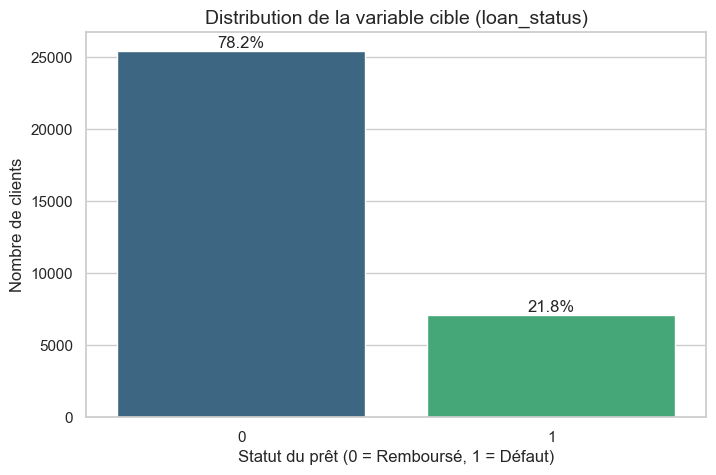

In [17]:
# Distribution de la variable cible 'loan_status' (0 = Non Défaut, 1 = Défaut)
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='loan_status', data=df, palette='viridis')
plt.title('Distribution de la variable cible (loan_status)', fontsize=14)
plt.xlabel('Statut du prêt (0 = Remboursé, 1 = Défaut)', fontsize=12)
plt.ylabel('Nombre de clients', fontsize=12)

# Ajout des pourcentages sur les barres
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=12)

plt.show()


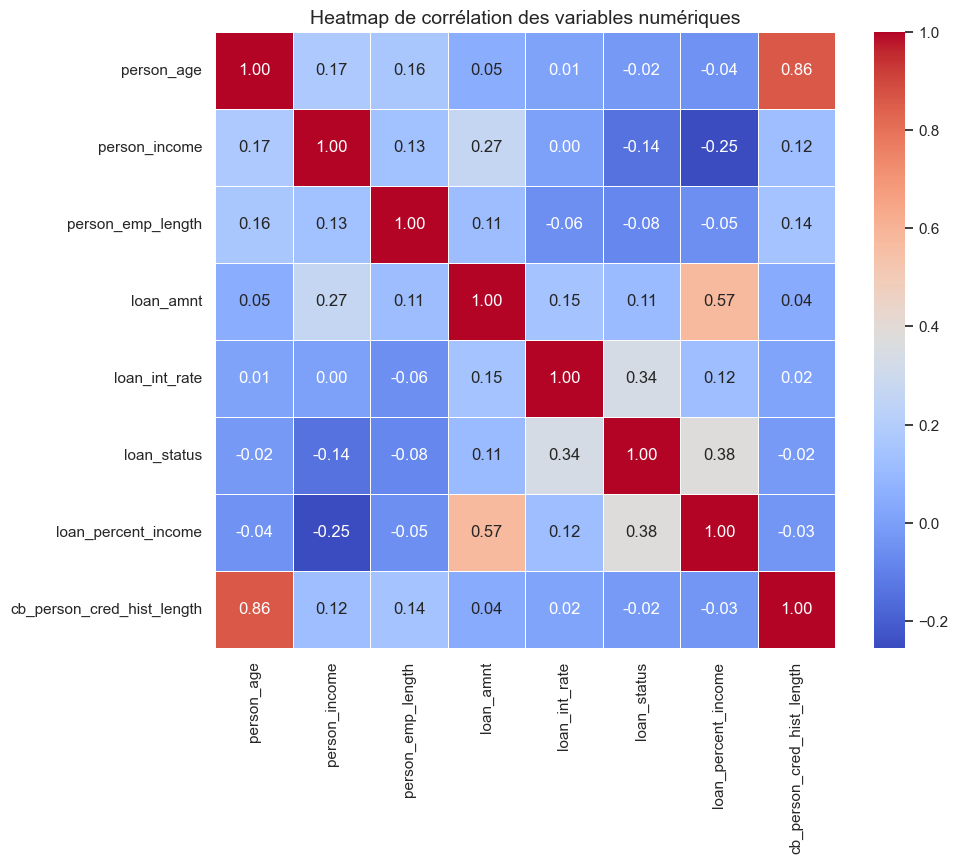

In [18]:
# Heatmap de corrélation
plt.figure(figsize=(10, 8))
# On ne sélectionne que les variables numériques pour la corrélation
corr_matrix = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Heatmap de corrélation des variables numériques', fontsize=14)
plt.show()


Valeurs manquantes par colonne :
 loan_int_rate        3116
person_emp_length     895
dtype: int64


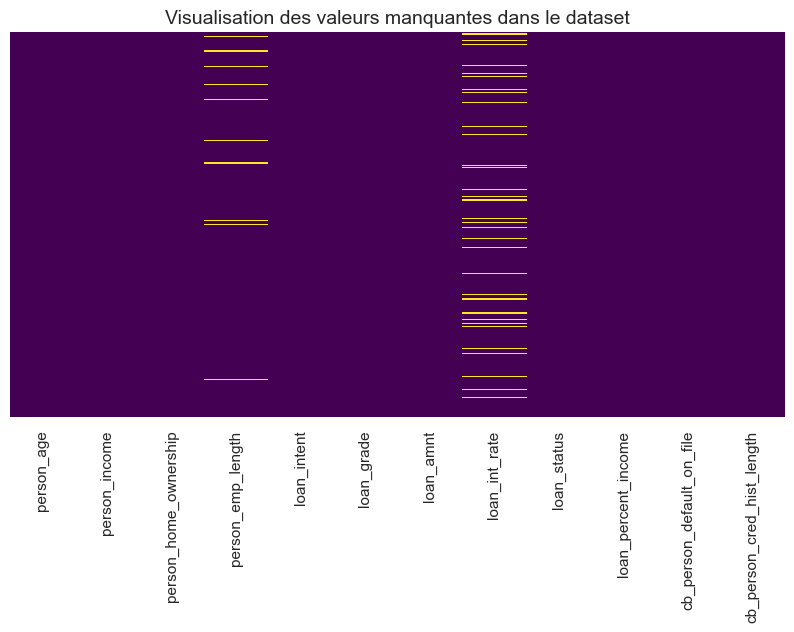

In [19]:
# Analyse des valeurs manquantes
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)
print("Valeurs manquantes par colonne :\n", missing_values)

# Visualisation des valeurs manquantes (utilisation de seaborn)
plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Visualisation des valeurs manquantes dans le dataset', fontsize=14)
plt.show()

# NB: Si la librairie missingno est installée, nous pouvons utiliser :
# import missingno as msno
# msno.matrix(df)


## 4. NETTOYAGE
Traitement des valeurs manquantes, gestion des valeurs aberrantes (outliers) et encodage des données catégorielles (Feature Engineering).


In [20]:
# Copie du dataset pour le nettoyage
df_clean = df.copy()

# 1. Imputation des valeurs manquantes par la médiane pour les variables numériques
# Les colonnes concernées semblent être person_emp_length et loan_int_rate
df_clean['person_emp_length'].fillna(df_clean['person_emp_length'].median(), inplace=True)
df_clean['loan_int_rate'].fillna(df_clean['loan_int_rate'].median(), inplace=True)

print("Valeurs manquantes restantes :", df_clean.isnull().sum().sum())


Valeurs manquantes restantes : 0


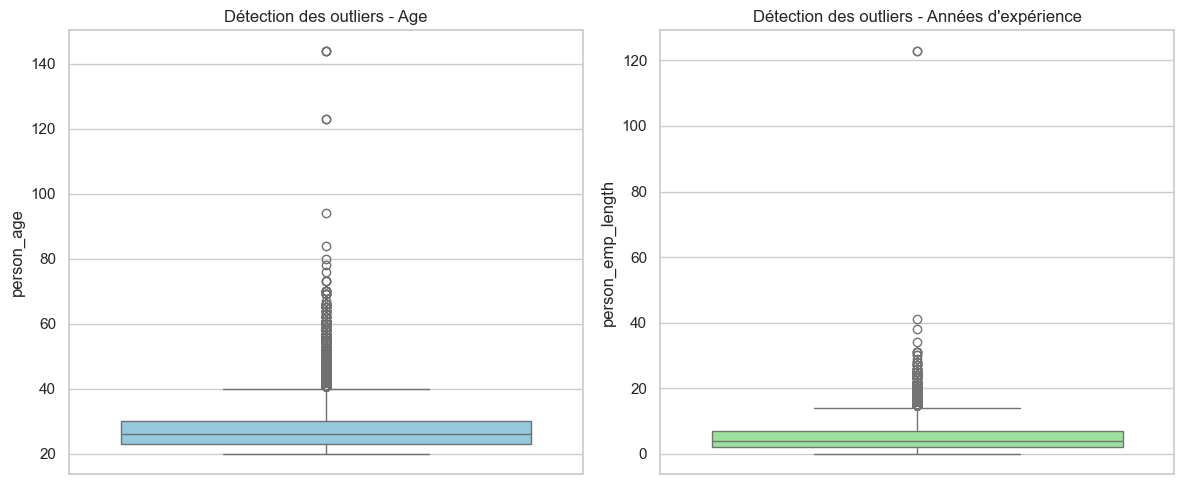

In [21]:
# 2. Détection des outliers avec boxplots pour person_age et person_emp_length
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(y=df_clean['person_age'], ax=axes[0], color='skyblue')
axes[0].set_title('Détection des outliers - Age', fontsize=12)

sns.boxplot(y=df_clean['person_emp_length'], ax=axes[1], color='lightgreen')
axes[1].set_title("Détection des outliers - Années d'expérience", fontsize=12)

plt.tight_layout()
plt.show()

# Suppression des valeurs aberrantes irréalistes (ex: age > 100, ancienneté > 60)
df_clean = df_clean[df_clean['person_age'] <= 100]
df_clean = df_clean[df_clean['person_emp_length'] <= 60]


In [22]:
# 3. Encodage des variables catégorielles et préparation des features/target
X = df_clean.drop('loan_status', axis=1)
y = df_clean['loan_status']

# Séparation des variables numériques et catégorielles
num_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_features = X.select_dtypes(include=['object']).columns.tolist()

# Création du préprocesseur pour encoder les catégories et scaler les numériques
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_features)
    ])

# Affichage des types de variables
print(f"Variables numériques ({len(num_features)}) : {num_features}")
print(f"Variables catégorielles ({len(cat_features)}) : {cat_features}")


Variables numériques (7) : ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']
Variables catégorielles (4) : ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']


## 5. MODÉLISATION
Séparation des données en Train/Test et entraînement de plusieurs modèles de classification.


In [23]:
# Split train/test (80/20) avec stratify pour maintenir la proportion de la classe cible
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print(f"Taille du jeu d'entraînement : {X_train.shape}")
print(f"Taille du jeu de test : {X_test.shape}")


Taille du jeu d'entraînement : (26059, 11)
Taille du jeu de test : (6515, 11)


In [24]:
# Initialisation des modèles
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

# Dictionnaire pour stocker les résultats
results = {}

# Entraînement et évaluation des modèles
for name, model in models.items():
    # Création du pipeline
    pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('classifier', model)])
    
    # Entraînement
    pipeline.fit(X_train, y_train)
    
    # Prédictions
    y_pred = pipeline.predict(X_test)
    y_pred_proba = pipeline.predict_proba(X_test)[:, 1]
    
    # Calcul des métriques
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    # Stockage
    results[name] = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1 Score': f1, 'AUC-ROC': roc_auc}
    # On sauvegarde le pipeline du meilleur modèle plus tard si nécessaire
    if name == 'XGBoost':
        xgb_pipeline = pipeline

# Tableau comparatif des métriques
results_df = pd.DataFrame(results).T
display(results_df.style.highlight_max(axis=0, color='lightgreen'))


,Accuracy,Precision,Recall,F1 Score,AUC-ROC
Logistic Regression,0.864006,0.768844,0.538353,0.633278,0.862369
Random Forest,0.929240,0.958015,0.706545,0.813285,0.926560
XGBoost,0.933845,0.959184,0.727657,0.827531,0.948303


## 6. RÉSULTATS
Comparaison visuelle des performances (Courbe ROC), matrice de confusion du modèle le plus performant et analyse de l'importance des variables.


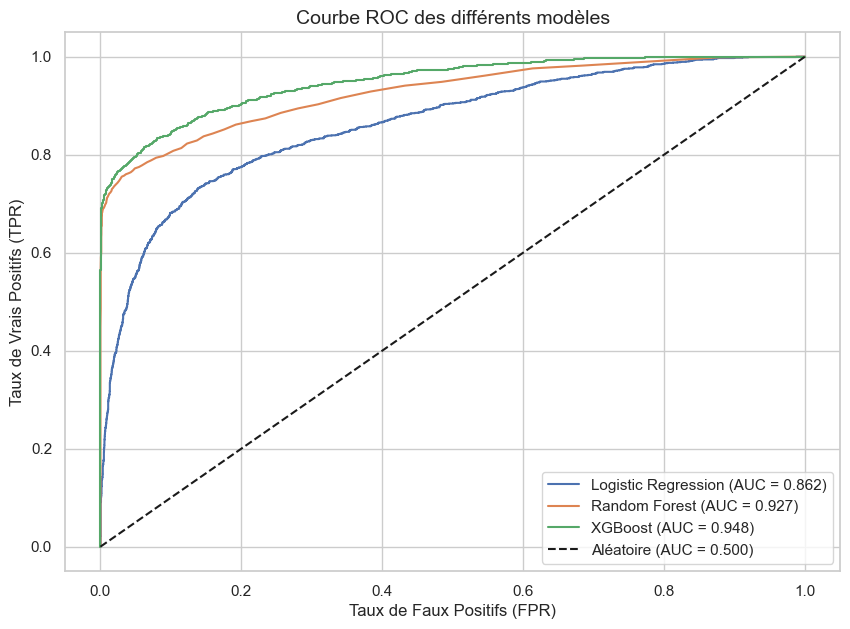

In [25]:
# Courbe ROC pour les 3 modèles
plt.figure(figsize=(10, 7))

for name, model in models.items():
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])
    pipeline.fit(X_train, y_train)
    y_pred_proba = pipeline.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    auc_score = roc_auc_score(y_test, y_pred_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label='Aléatoire (AUC = 0.500)')
plt.xlabel('Taux de Faux Positifs (FPR)', fontsize=12)
plt.ylabel('Taux de Vrais Positifs (TPR)', fontsize=12)
plt.title('Courbe ROC des différents modèles', fontsize=14)
plt.legend(loc='lower right', fontsize=11)
plt.show()


Meilleur modèle sélectionné : XGBoost


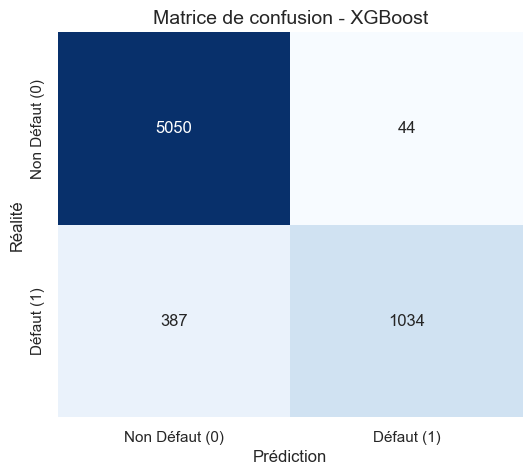

In [26]:
# Matrice de confusion pour le meilleur modèle (généralement XGBoost)
best_model_name = results_df['AUC-ROC'].idxmax()
print(f"Meilleur modèle sélectionné : {best_model_name}")

# On récupère les prédictions du pipeline XGBoost (sauvegardé précédemment)
y_pred_xgb = xgb_pipeline.predict(X_test)
cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Non Défaut (0)', 'Défaut (1)'],
            yticklabels=['Non Défaut (0)', 'Défaut (1)'])
plt.title(f'Matrice de confusion - {best_model_name}', fontsize=14)
plt.ylabel('Réalité', fontsize=12)
plt.xlabel('Prédiction', fontsize=12)
plt.show()


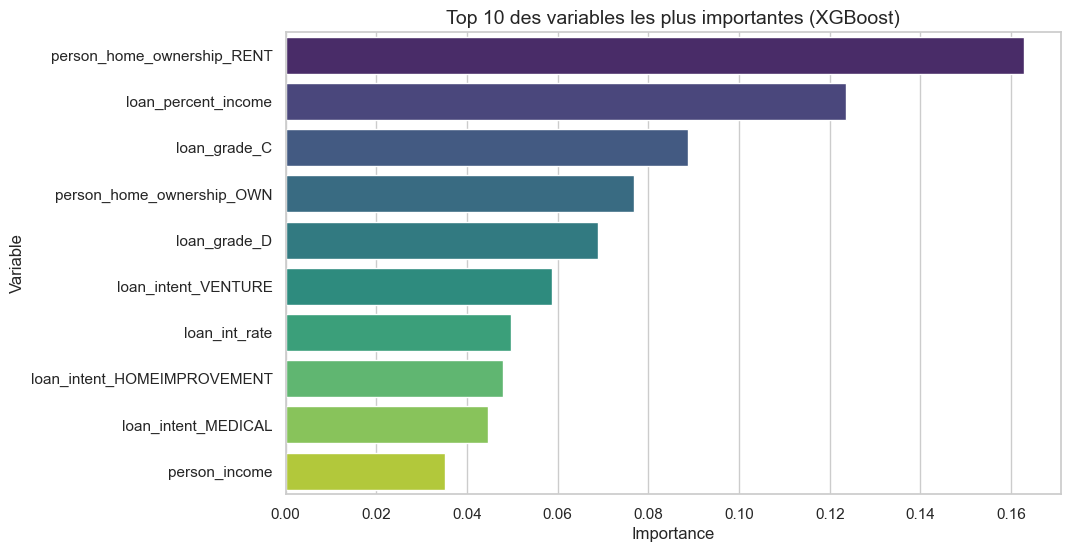

In [27]:
# Feature Importance (Top 10 variables) pour XGBoost
xgb_model = xgb_pipeline.named_steps['classifier']

# Récupération du nom des features après encodage OneHot
cat_encoder = xgb_pipeline.named_steps['preprocessor'].named_transformers_['cat']
cat_features_encoded = cat_encoder.get_feature_names_out(cat_features).tolist()
all_features = num_features + cat_features_encoded

# Création du DataFrame d'importance
feature_importances = pd.DataFrame({
    'Feature': all_features,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Visualisation des 10 features les plus importantes
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importances.head(10), palette='viridis')
plt.title('Top 10 des variables les plus importantes (XGBoost)', fontsize=14)
plt.xlabel("Importance", fontsize=12)
plt.ylabel("Variable", fontsize=12)
plt.show()


## 7. CONCLUSION BUSINESS

### 🎯 Insights Actionnables et Recommandations
1. **Plafond lié aux Revenus et Propriété** : L'importance du ratio prêt/revenu (`loan_percent_income`) et de la location du logement (ex. `person_home_ownership_RENT`) est très forte. **Recommandation** : Imposer un plafond strict du montant accordé si le loyer + le crédit dépassent 35-40% du revenu net de l'adhérent.
2. **Historique de Défaut et Grades Défavorables** : La présence d'un défaut passé (ex: `cb_person_default_on_file_Y`) ou de prêts gradés D, E, F est un signal d'alarme fort. **Recommandation** : Durcir automatiquement les conditions (taux plus élevé, garantie supplémentaire, ou refus) pour les clients ayant déjà fait un défaut antérieur ou dont le passif n'est pas bon.
3. **Optimiser les taux pour les profils sûrs** : Les adhérents propriétaires de leur logement (`MORTGAGE` ou `OWN`) avec un long historique de crédit remboursent globalement beaucoup mieux. **Recommandation** : Proposer des taux très attractifs pour ces profils en acquisition de résidence principale ou consolidation, afin de fidéliser cette clientèle peu risquée et améliorer le portefeuille.

### ⚠️ Segment de clients à risque identifié
**Le profil le plus risqué** correspond souvent à un jeune emprunteur (souvent moins de 25 ans), locataire de son logement (`RENT`), demandant un crédit dont le montant représente une grosse proportion de ses revenus (`loan_percent_income` élevé), souvent pour des motifs plus risqués, avec peu d'historique de crédit ou un historique marqué d'un défaut. Ce segment devrait systématiquement faire l'objet d'une analyse manuelle par un conseiller senior avec demande d'un cosignataire ou de garanties solides avant tout octroi de prêt.
